In [46]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from functools import reduce
import umap
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import commons, models, utils, losses, lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDiseaseBinaryBatchSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import (
            confusion_matrix, accuracy_score,
            balanced_accuracy_score,
            roc_auc_score, roc_curve
        )

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, ClassifierOutputSoftmaxTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_3534574/1585893356.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [3]:
now_experiment = "resnet34_gtgram_deltadelta"
parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")
args = parser.parse_args(["--model_name", now_experiment])

model_dir = os.path.join("./logs", args.model_name)
config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()
config = json.loads(data)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training
hps.data.ssccl_training = hps.train.ssccl_training
hps.model.spk_dim = 0

logger = utils.get_logger(hps.model_dir)
import sys, importlib.util, shutil, tempfile
temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)
pool_net = getattr(model_net, hps.model.pooling_model)

hps.model.lora_finetune = False
pool_model = pool_net(hps.model.feature_dim, **hps.model)

runner_lightning = lightning_wrapper.CoughClassificationRunner(pool_model, hps=hps, custom_logger=logger, class_weights=[])
runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
    os.path.join(f"{hps.model_dir}/best_model.ckpt"),
    model=pool_model,
    hps=hps, custom_logger=logger
)
runner_lightning.eval()

df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)
target_labels = df_train[hps.data.target_column]

with open(os.path.join(hps.model_dir, "info_fold.pkl"), "rb") as f:
    info_fold = pickle.load(f)
    best_fold_idx = info_fold["best_fold_idx"]
    fold_metrics = info_fold["fold_metrics"]


val_dataset = CoughDatasets(df_test.values, hps.data,
                                wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", train=False)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False,
                        batch_size=hps.train.batch_size, pin_memory=True, drop_last=False, collate_fn=collate_fn)


INFO:resnet34_gtgram_deltadelta:Trainable params: 7289697 | Total params: 7289697 | Trainable%: 100.00% | Size: 7.29M
INFO:resnet34_gtgram_deltadelta:Trainable params: 7289697 | Total params: 7289697 | Trainable%: 100.00% | Size: 7.29M


In [10]:
val_batches = list(val_loader)
wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = random.choice(val_batches)
audio = audio.cuda()
attention_masks = attention_masks.cuda()
out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
logits = out_model['disease_logits']

probs = torch.sigmoid(logits).squeeze(-1) 
preds = (probs >= 0.5).long().cpu().numpy()
labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

# mel = audio.squeeze(0)
# mel_norm = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
# mel_np = mel_norm.cpu().numpy()

# mel_np = np.flipud(mel_np)
# cmap = cm.get_cmap("viridis")          
# mel_rgb = cmap(mel_np)[..., :3]       

# print(preds)
# print(labels)

In [74]:
index_selected = 0
mel = audio[index_selected].squeeze(0).cpu()

def minmax_norm(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)

# split
mel_static = mel[0:80]
mel_delta = mel[80:160]
mel_deltadelta = mel[160:240]

# normalize independently
mel_static_n = minmax_norm(mel_static)
mel_delta_n = minmax_norm(mel_delta)
mel_deltadelta_n = minmax_norm(mel_deltadelta)

# recombine
mel_norm = np.vstack([
    mel_static_n,
    mel_delta_n,
    mel_deltadelta_n
])

mel_np = mel_norm
mel_np = np.flipud(mel_np)

cmap = cm.get_cmap("viridis")
mel_rgb = cmap(mel_np)[..., :3]

/tmp/ipykernel_3534574/1693937014.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


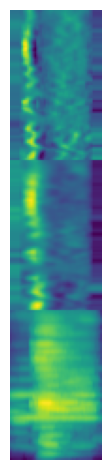

In [75]:
plt.imshow(mel_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

In [76]:
class ClassifierOutputSoftmaxTargetHola:
    def __init__(self, category):
        self.category = category

    def __call__(self, model_output):
        if len(model_output.shape) == 1:
            return torch.softmax(model_output, dim=-1)[self.category]
        return torch.softmax(model_output, dim=-1)[:, self.category]
    
class CAMWrapper(torch.nn.Module):
    def __init__(self, lightning_model):
        super().__init__()
        self.lightning_model = lightning_model

    def forward(self, x):
        out = self.lightning_model(x)
        return out["disease_logits"]


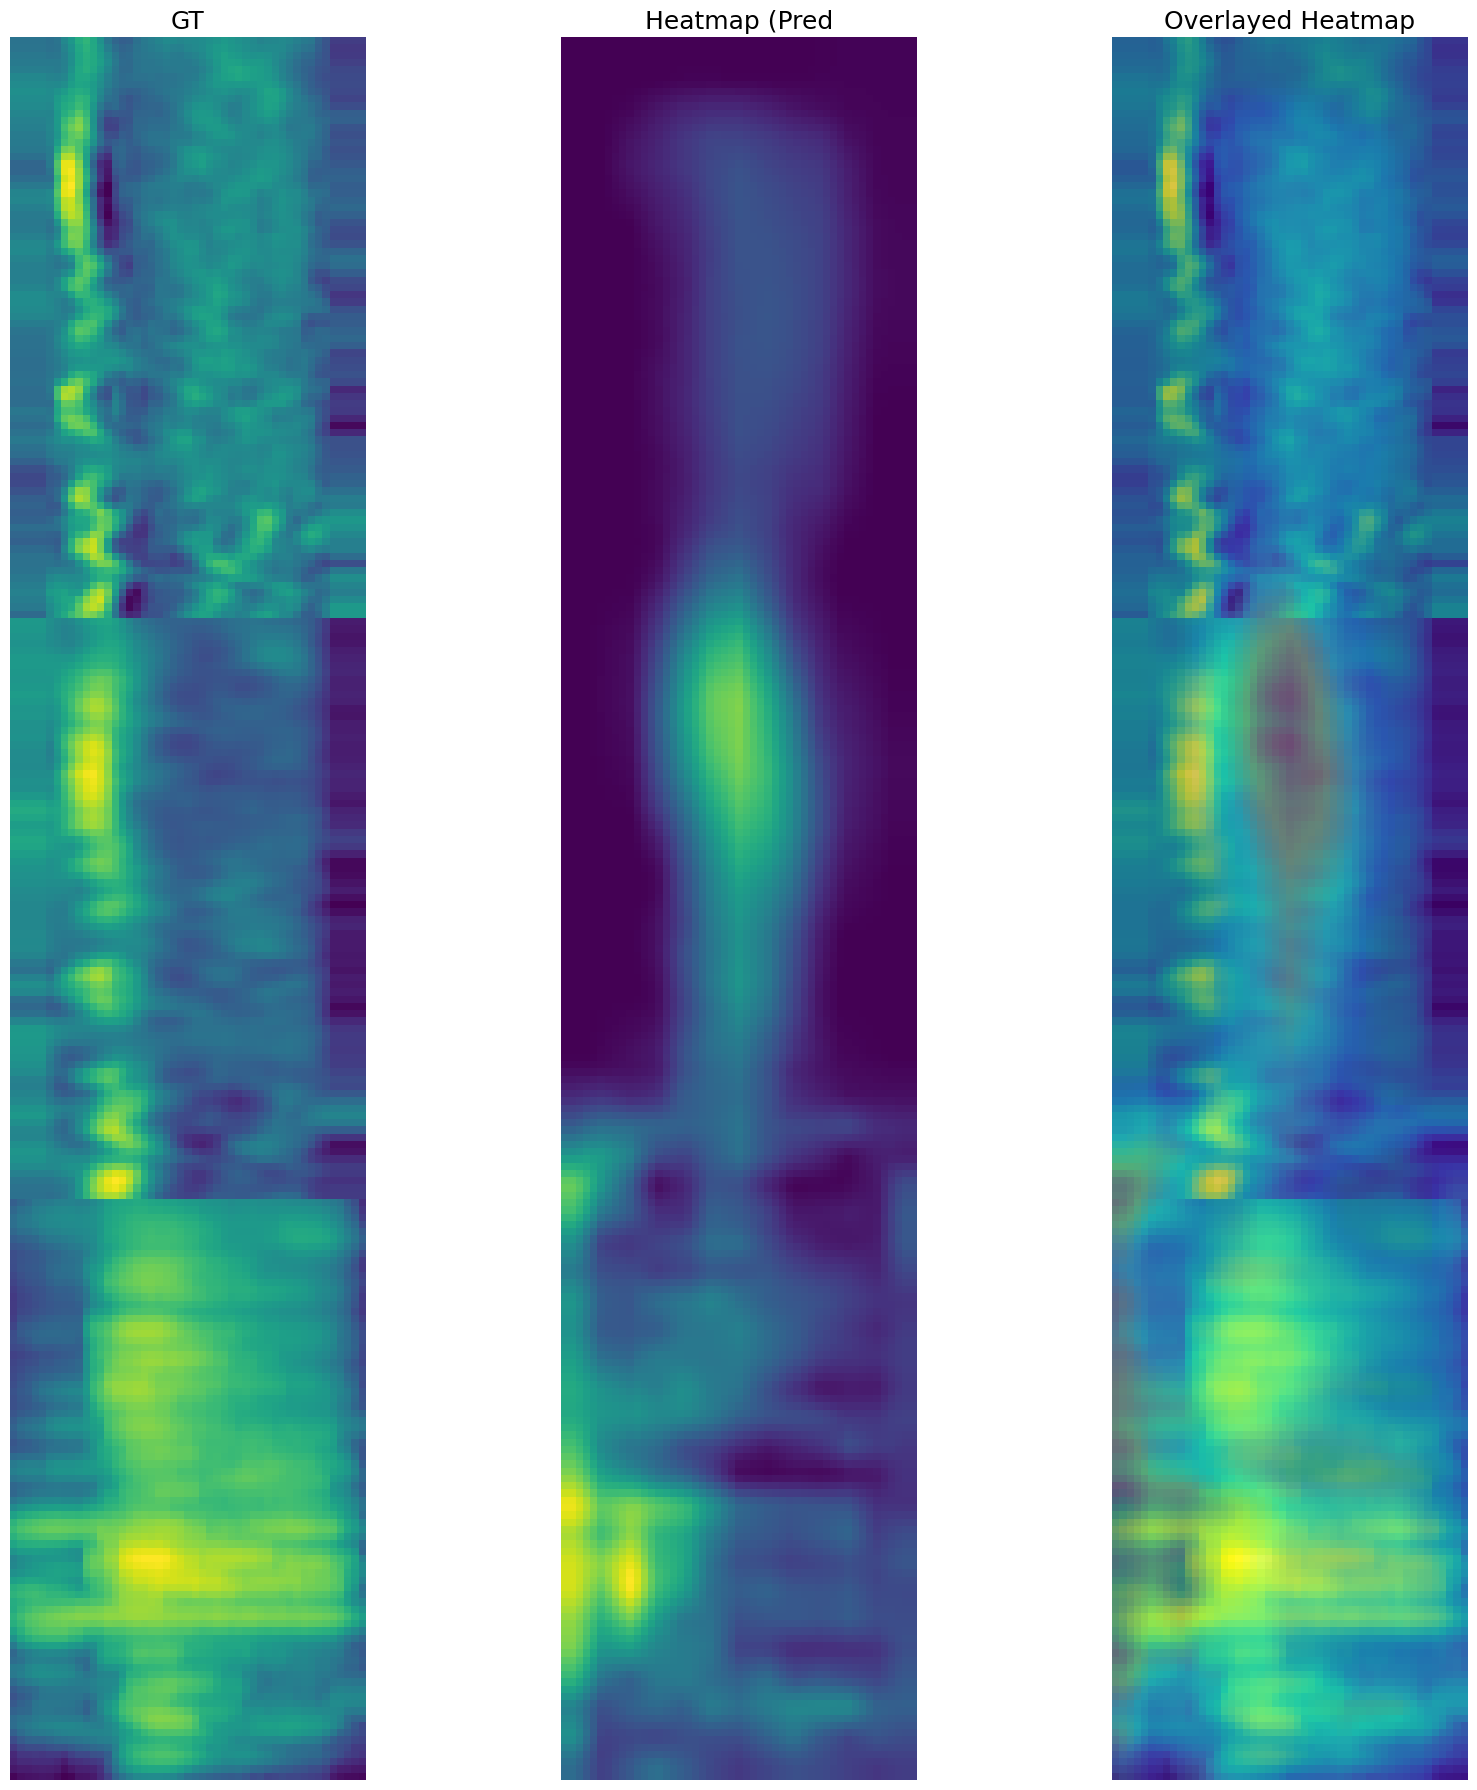

In [77]:
cam_model = CAMWrapper(runner_lightning.model)

target_layers = [runner_lightning.model.layer4, runner_lightning.model.layer3]
input_tensor = audio[index_selected]#.unsqueeze(1)
image_original = mel_rgb
targets = [ClassifierOutputTarget(0)]

with GradCAM(model=cam_model, target_layers=target_layers) as cam:
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = np.flipud(grayscale_cam[0, :])
  visualization = show_cam_on_image(image_original, grayscale_cam, use_rgb=True, image_weight=0.8)
  model_outputs = cam.outputs

images = [image_original, grayscale_cam, visualization]
titles = [f"GT",
            f"Heatmap (Pred",
            "Overlayed Heatmap"]

plt.figure(figsize=(21, 18))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(titles[i], fontdict={"size": 18})
    plt.tight_layout()
plt.show()

In [13]:
audio.shape

torch.Size([128, 1, 240, 49])

In [78]:
preds

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [79]:
labels

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:

test_wavnames = []
test_preds = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(val_loader), total=len(val_loader)):
        wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
        logits = out_model['disease_logits']

        probs = torch.sigmoid(logits).squeeze(-1) 
        preds = (probs >= 0.5).long()

        test_wavnames.extend(wavnames)
        test_preds.append(probs.cpu())

del audio, attention_masks
test_wavnames = np.array(test_wavnames)
test_preds = torch.cat(test_preds, dim=0).numpy()

df_cough_result = pd.DataFrame({
    "path_file": test_wavnames,
    "cough_probs": test_preds
})

In [ ]:
pool_model.eval()
all_wavnames, all_preds, all_labels, all_embeddings = [], [], [], []

with torch.no_grad():
    for _, (wav_names, audio, attention_masks, dse_ids, _) in enumerate(tqdm(val_loader, desc=f"Eval")):
        audio = audio.cuda(non_blocking=True).float().squeeze(1)
        attention_masks = attention_masks.cuda(non_blocking=True).float()
        dse_ids = dse_ids.cuda(non_blocking=True).float()

        raw_outputs = pool_model(audio, attention_mask=attention_masks)
        logits = raw_outputs["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

        all_wavnames.extend(wav_names)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels)
        all_embeddings.extend(raw_outputs["embeddings"].cpu().numpy())
        break

In [27]:
import random

val_batches = list(val_loader)
wav_names, audio, attention_masks, dse_ids, extra = random.choice(val_batches)
audio = audio.cuda(non_blocking=True).float().squeeze(1)
attention_masks = attention_masks.cuda(non_blocking=True).float()

raw_outputs = pool_model(audio.unsqueeze(1), attention_mask=attention_masks)
preds = torch.argmax(raw_outputs, dim=1)
labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)[0]

mel = audio.squeeze(0)
mel_norm = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
mel_np = mel_norm.cpu().numpy()

mel_np = np.flipud(mel_np)
cmap = cm.get_cmap("viridis")          
mel_rgb = cmap(mel_np)[..., :3]       

print(preds)
print(labels)

tensor([1], device='cuda:0')
1


/tmp/ipykernel_2680872/3589764533.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


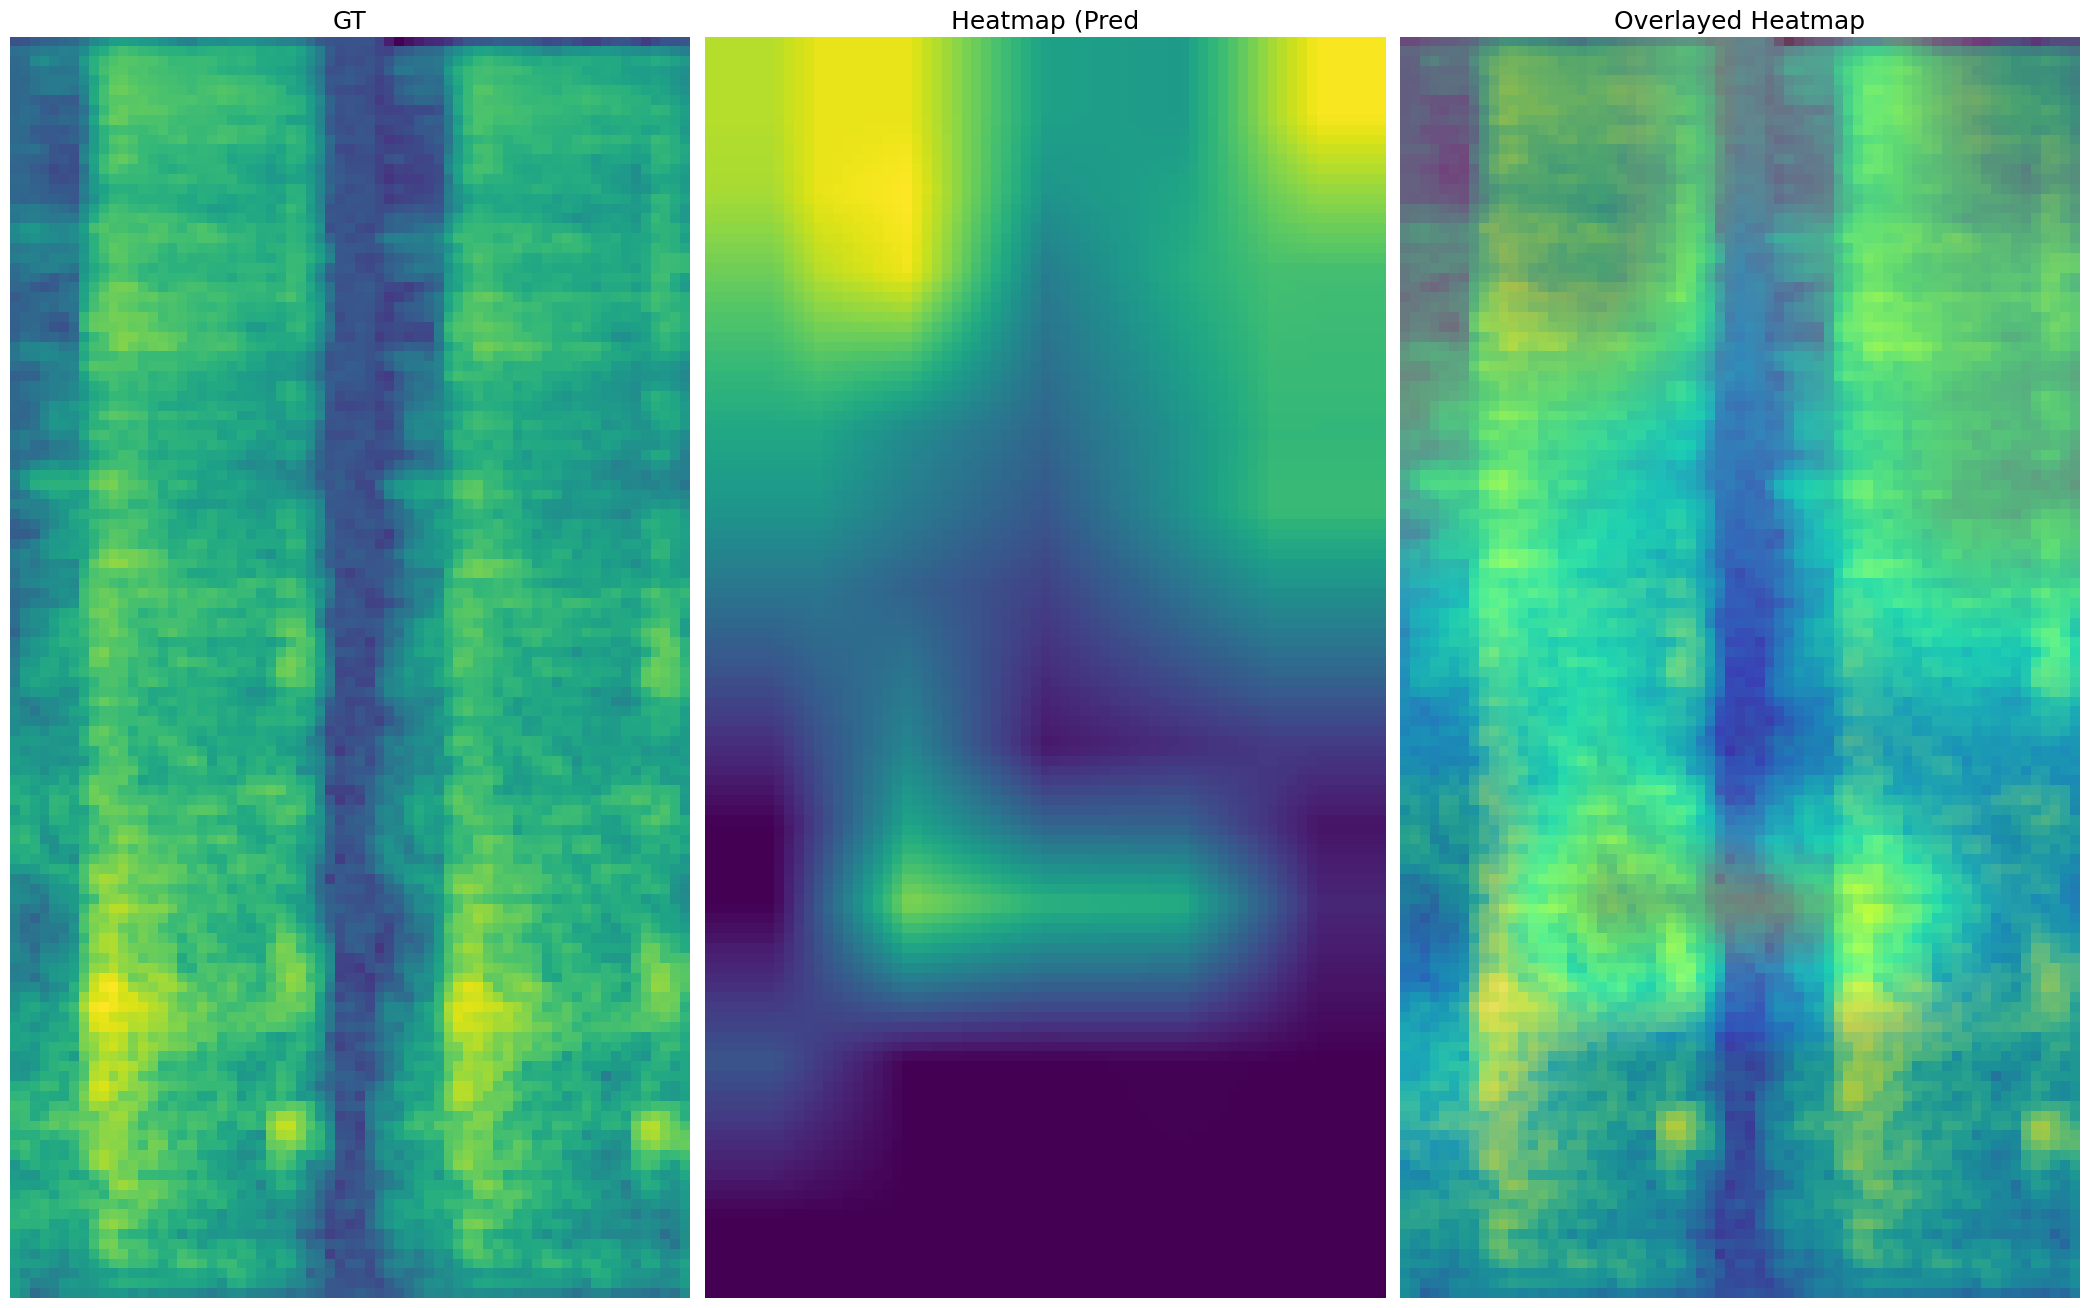

In [28]:
target_layers = [pool_model.backbone[-1], pool_model.backbone[-2]]
input_tensor = audio.unsqueeze(1)
image_original = mel_rgb
targets = [ClassifierOutputTarget(labels)]

with GradCAM(model=pool_model, target_layers=target_layers) as cam:
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = np.flipud(grayscale_cam[0, :])
  visualization = show_cam_on_image(image_original, grayscale_cam, use_rgb=True, image_weight=0.8)
  model_outputs = cam.outputs

images = [image_original, grayscale_cam, visualization]
titles = [f"GT",
            f"Heatmap (Pred",
            "Overlayed Heatmap"]

plt.figure(figsize=(21, 18))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(titles[i], fontdict={"size": 18})
    plt.tight_layout()
plt.show()